# Модуль 1. Что значит «работает»

Ноутбук к [модулю 1](https://drobyshevdev.github.io/lemma/modules/01-claim-baseline-noise/).

Здесь мы работаем на **симулированном** эксперименте, где истинный ответ известен заранее. Это важно: на настоящих данных истину не видно, и понять, где наши оценки врут, невозможно. Здесь — видно.

Запускается за секунды на любом ноутбуке. Нужны только `numpy` и `matplotlib`.

**Читайте дважды.** Первый раз — сверху вниз, ничего не меняя. Второй — ломая: в конце каждого раздела есть, что сломать.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Один генератор на весь ноутбук, с явным зерном: результаты воспроизводимы,
# и это первое, что должно быть в любом эксперименте.
RNG = np.random.default_rng(20260803)

plt.rcParams["figure.figsize"] = (9, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"numpy {np.__version__}")

numpy 1.26.4


## 1. Почему в дисперсии делят на $n-1$

Утверждение из текста: деление на $n$ систематически **занижает** дисперсию, потому что среднее мы посчитали по этим же данным.

Не будем верить на слово. Возьмём распределение с известной дисперсией и проверим численно.

In [2]:
TRUE_SIGMA = 3.0
TRUE_VAR = TRUE_SIGMA ** 2
n = 5              # маленькая выборка: эффект виден яснее
n_experiments = 50_000

samples = RNG.normal(loc=10.0, scale=TRUE_SIGMA, size=(n_experiments, n))

# Считаем обе версии руками, чтобы было видно, чем они отличаются.
means = samples.mean(axis=1, keepdims=True)
squared_deviations = ((samples - means) ** 2).sum(axis=1)

var_divide_by_n = squared_deviations / n
var_divide_by_n_minus_1 = squared_deviations / (n - 1)

print(f"истинная дисперсия:      {TRUE_VAR:.4f}")
print(f"в среднем при делении /n:      {var_divide_by_n.mean():.4f}")
print(f"в среднем при делении /(n-1):  {var_divide_by_n_minus_1.mean():.4f}")
print()
print(f"занижение при /n: {100 * (1 - var_divide_by_n.mean() / TRUE_VAR):.1f}%")
print(f"предсказанное теорией занижение: {100 / n:.1f}%")

истинная дисперсия:      9.0000
в среднем при делении /n:      7.1931
в среднем при делении /(n-1):  8.9914

занижение при /n: 20.1%
предсказанное теорией занижение: 20.0%


Занижение ровно $1/n$ — не приблизительно, а точно, и это не совпадение: множитель между двумя версиями и есть $\frac{n-1}{n}$.

**Сломайте:** поставьте `n = 50`. Куда денется разница и почему на больших выборках спор о $n$ против $n-1$ никого не волнует?

## 2. Два метода с известной разницей

Теперь главное. Смоделируем два метода. Мы **знаем** истину: метод B лучше метода A на 2 единицы. Вопрос — увидим ли мы это в эксперименте.

Разброс между зёрнами возьмём реалистичный для RL: сравнимый с разницей между методами.

In [3]:
TRUE_A, TRUE_B = 100.0, 102.0   # B действительно лучше на 2
SEED_NOISE = 4.0                # разброс между зёрнами — вдвое больше разницы

def run(method_mean, n_seeds, rng):
    """Один «эксперимент»: n_seeds запусков метода с истинным средним method_mean."""
    return rng.normal(loc=method_mean, scale=SEED_NOISE, size=n_seeds)

# Один запуск каждого метода — ровно то, что показывают в плохой статье.
a_single = run(TRUE_A, 1, RNG)[0]
b_single = run(TRUE_B, 1, RNG)[0]

print(f"метод A, один запуск: {a_single:.1f}")
print(f"метод B, один запуск: {b_single:.1f}")
print(f"вывод по одному запуску: победил {'B' if b_single > a_single else 'A'}")
print(f"истина: победил B (на {TRUE_B - TRUE_A:.0f})")

метод A, один запуск: 94.8
метод B, один запуск: 101.9
вывод по одному запуску: победил B
истина: победил B (на 2)


Один запуск может дать любой ответ. Насколько это «любой» — посчитаем, а не будем гадать.

In [4]:
def fraction_a_wins(n_seeds, n_experiments=20_000, rng=None):
    """Доля экспериментов, где худший метод A выигрывает по среднему.

    Это и есть вероятность опубликовать неверный вывод, если решать
    сравнением средних по n_seeds зёрнам.
    """
    rng = rng or np.random.default_rng(0)
    a = rng.normal(TRUE_A, SEED_NOISE, size=(n_experiments, n_seeds)).mean(axis=1)
    b = rng.normal(TRUE_B, SEED_NOISE, size=(n_experiments, n_seeds)).mean(axis=1)
    return float((a > b).mean())

seed_counts = [1, 3, 5, 10, 20, 50, 100]
wrong = [fraction_a_wins(k, rng=np.random.default_rng(1)) for k in seed_counts]

print("зёрен   доля неверных выводов")
for k, w in zip(seed_counts, wrong):
    print(f"{k:>5}   {w:>6.1%}   {'#' * round(w * 100)}")

зёрен   доля неверных выводов
    1    36.1%   ####################################
    3    26.2%   ##########################
    5    20.8%   #####################
   10    13.0%   #############
   20     5.8%   ######
   50     0.6%   #
  100     0.0%   


Прочитайте эту таблицу внимательно. При трёх зёрнах — типичном числе в статьях — **худший метод объявляется лучшим примерно в четверти случаев**. Не из-за обмана: просто три числа мало что говорят.

И заметьте, как медленно падает ошибка: чтобы уполовинить её, зёрен нужно вчетверо больше. Это тот самый $\sqrt{n}$ из формулы стандартной ошибки.

**Сломайте:** поставьте `SEED_NOISE = 1.0` (разброс вдвое меньше разницы) и пересчитайте. Затем `SEED_NOISE = 8.0`. Что важнее для надёжности вывода — число зёрен или отношение разницы к шуму?

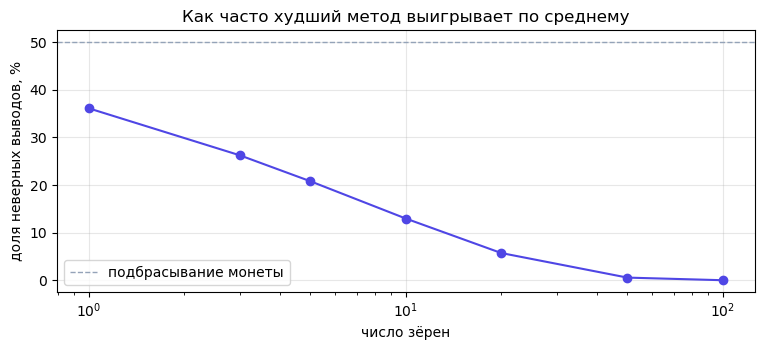

In [5]:
fig, ax = plt.subplots()
ax.plot(seed_counts, [100 * w for w in wrong], marker="o", color="#4f46e5")
ax.axhline(50, color="#94a3b8", ls="--", lw=1, label="подбрасывание монеты")
ax.set_xscale("log")
ax.set_xlabel("число зёрен")
ax.set_ylabel("доля неверных выводов, %")
ax.set_title("Как часто худший метод выигрывает по среднему")
ax.legend()
plt.show()

## 3. Один эксперимент целиком, как в статье

Теперь сделаем то, что должно было быть в статье: десять зёрен, среднее, стандартная ошибка, интервал.

In [6]:
N_SEEDS = 10
rng = np.random.default_rng(7)
a = run(TRUE_A, N_SEEDS, rng)
b = run(TRUE_B, N_SEEDS, rng)

def summary(x, name):
    mean = x.mean()
    s = x.std(ddof=1)                  # ddof=1 — это и есть деление на n-1
    se = s / np.sqrt(len(x))
    lo, hi = mean - 1.96 * se, mean + 1.96 * se
    print(f"{name}: среднее {mean:6.2f}   s {s:5.2f}   SE {se:5.2f}   95% ДИ [{lo:6.2f}, {hi:6.2f}]")
    return lo, hi

a_lo, a_hi = summary(a, "метод A")
b_lo, b_hi = summary(b, "метод B")

overlap = a_hi >= b_lo and b_hi >= a_lo
print()
print(f"интервалы перекрываются: {overlap}")
print("вывод:", "разница не показана" if overlap else "разница показана")
print(f"истина: разница есть, она равна {TRUE_B - TRUE_A:.0f}")

метод A: среднее  99.19   s  2.72   SE  0.86   95% ДИ [ 97.50, 100.88]
метод B: среднее 100.28   s  3.57   SE  1.13   95% ДИ [ 98.07, 102.49]

интервалы перекрываются: True
вывод: разница не показана
истина: разница есть, она равна 2


Обратите внимание на возможный исход: разница **есть**, а вывод — «не показана». Это не ошибка метода. Это честный ответ «данных не хватает», и он гораздо полезнее уверенного неверного утверждения.

**Сломайте:** увеличьте `N_SEEDS` до 40. Поменяйте зерно `default_rng(7)` на несколько других при `N_SEEDS = 10` и посмотрите, как часто вывод меняется.

## 4. Среднее против IQM

Смоделируем реалистичную для RL картину: большинство запусков работает, часть расходится.

In [7]:
def iqm(x):
    """Межквартильное среднее: отбросить худшую и лучшую четверть, усреднить середину."""
    x = np.sort(np.asarray(x))
    k = len(x) // 4
    trimmed = x[k:len(x) - k] if k else x
    return float(trimmed.mean())

rng = np.random.default_rng(11)
runs = rng.normal(100, 3, size=20)
runs[[2, 9, 15]] = [12.0, 8.0, 15.0]      # три разошедшихся запуска

print("результаты:", np.round(np.sort(runs), 1))
print()
print(f"среднее: {runs.mean():6.1f}")
print(f"медиана: {np.median(runs):6.1f}")
print(f"IQM:     {iqm(runs):6.1f}")
print()
print("Типичный работающий запуск даёт около 100. Какая сводка это отражает?")

результаты: [  8.   12.   15.   98.4  98.5  98.9  99.1  99.4  99.5  99.6  99.7  99.8
 100.1 101.7 102.  102.1 102.2 102.5 104.1 104.7]

среднее:   87.4
медиана:   99.7
IQM:      100.0

Типичный работающий запуск даёт около 100. Какая сводка это отражает?


!!! Здесь легко сделать неверный вывод: «значит, надо всегда брать IQM».

Нет. Расхождения — это **свойство метода**, а не помеха. Метод, который расходится в 15 % запусков, хуже метода, который не расходится, даже если IQM у них одинаковый. IQM отвечает на вопрос «что бывает, когда работает»; долю расхождений надо сообщать **отдельно**, а не прятать за устойчивой сводкой.

**Сломайте:** сделайте расходящимися десять запусков из двадцати. Посмотрите, что станет с IQM, и сформулируйте, почему одного числа здесь уже недостаточно.

## 5. Бутстрэп

Для IQM формулы стандартной ошибки нет. Бутстрэп работает для любой статистики.

In [8]:
def bootstrap_ci(values, statistic, n_resamples=10_000, seed=0):
    """95% доверительный интервал для любой статистики.

    Пересэмплирование с возвращением имитирует повторение эксперимента:
    выборка — наше лучшее приближение к тому, откуда пришли данные.
    """
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    draws = rng.choice(values, size=(n_resamples, len(values)), replace=True)
    stats = np.array([statistic(row) for row in draws])
    return np.percentile(stats, [2.5, 97.5])

for name, stat in [("среднее", np.mean), ("медиана", np.median), ("IQM", iqm)]:
    lo, hi = bootstrap_ci(runs, stat)
    print(f"{name:>8}: {stat(runs):6.1f}   95% ДИ [{lo:6.1f}, {hi:6.1f}]   ширина {hi - lo:5.1f}")

 среднее:   87.4   95% ДИ [  73.1,  100.6]   ширина  27.5
 медиана:   99.7   95% ДИ [  99.0,  101.9]   ширина   2.9
     IQM:  100.0   95% ДИ [  90.5,  101.2]   ширина  10.7


Сравните ширину интервалов. У среднего он шире — выбросы бьют не только по оценке, но и по её точности.

Проверим, что бутстрэп не выдумывает: для среднего у нас есть формула, и они должны примерно совпасть.

In [9]:
clean = rng.normal(100, 3, size=30)      # без выбросов, чтобы формула была применима

se = clean.std(ddof=1) / np.sqrt(len(clean))
formula = (clean.mean() - 1.96 * se, clean.mean() + 1.96 * se)
boot = bootstrap_ci(clean, np.mean)

print(f"по формуле:  [{formula[0]:.2f}, {formula[1]:.2f}]")
print(f"бутстрэп:    [{boot[0]:.2f}, {boot[1]:.2f}]")
print("\nСовпадают — значит, бутстрэпу можно доверять там, где формулы нет.")

по формуле:  [98.08, 99.89]
бутстрэп:    [98.09, 99.88]

Совпадают — значит, бутстрэпу можно доверять там, где формулы нет.


**Сломайте:** уменьшите `n_resamples` до 100. Насколько нестабильным станет интервал при повторных запусках с разными `seed`? Сколько пересэмплирований на самом деле нужно?

## 6. Проверка покрытия

Мы говорили: 95-процентный интервал накрывает истинное значение примерно в 95 % экспериментов. Это проверяемое утверждение — проверим.

In [10]:
def coverage(n_seeds, n_experiments=3_000, seed=0):
    """Доля экспериментов, где 95% интервал накрыл истинное среднее."""
    rng = np.random.default_rng(seed)
    x = rng.normal(TRUE_A, SEED_NOISE, size=(n_experiments, n_seeds))
    means = x.mean(axis=1)
    se = x.std(axis=1, ddof=1) / np.sqrt(n_seeds)
    return float(((means - 1.96 * se <= TRUE_A) & (TRUE_A <= means + 1.96 * se)).mean())

print("зёрен   реальное покрытие (должно быть ~95%)")
for k in [3, 5, 10, 30, 100]:
    print(f"{k:>5}   {coverage(k):.1%}")

зёрен   реальное покрытие (должно быть ~95%)


    3   81.4%
    5   88.0%
   10   91.7%
   30   93.3%
  100   94.0%


При трёх зёрнах покрытие заметно ниже обещанных 95 %: множитель 1.96 верен для нормального распределения с **известной** дисперсией, а мы оценили её по трём точкам. Правильно здесь брать квантиль распределения Стьюдента, а не 1.96 — но настоящий вывод другой:

> При трёх зёрнах даже правильно построенный интервал обещает меньше, чем кажется.

**Сломайте:** замените 1.96 на `scipy.stats.t.ppf(0.975, df=n_seeds - 1)` (если `scipy` установлен) и посмотрите, восстановится ли покрытие.

## Итог

Что мы посчитали своими руками, а не приняли на веру:

1. Деление на $n-1$ убирает занижение ровно на $1/n$.
2. При трёх зёрнах худший метод объявляется лучшим примерно в четверти случаев.
3. Ошибка падает как $\sqrt{n}$ — вчетверо больше запусков ради вдвое лучшей точности.
4. IQM устойчив к расхождениям, но долю расхождений надо сообщать отдельно.
5. Бутстрэп совпадает с формулой там, где формула есть, и работает там, где её нет.
6. При малом числе зёрен интервал обещает больше, чем даёт.

Дальше — [часть 2 практики](https://drobyshevdev.github.io/lemma/modules/01-claim-baseline-noise/#2): проверить настоящее опубликованное заявление.